# Train a FlyImageClassifier on MNIST

This minimal example presents the same MNIST image to both eyes at their mapped L2 locations, propagates activity through a bilateral MaleCNS L2/Tm1 circuit, and trains the encoder responses, circuit parameters, and classification head.

Run `uv sync --extra cpu --all-groups` from the repository root and select its Python kernel. MNIST is downloaded once (about 11 MB); local MaleCNS files under `data/male-cns-v1.0` are reused, or the model loader downloads them on first use. Train on all 60,000 training images and evaluate on all 10,000 test images using mini-batches.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pyarrow.feather as feather
import trackio
from flax import nnx
from tqdm.auto import trange

from flyx.core import CircuitSpec, NeuronQuery as Q
from flyx.model import FlyConfig, FlyImageClassifier, FlyModel, VisualInputMap

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

In [2]:
experiment_configs = {
    "dataset": "MNIST",
    "epochs": 5,
    "batch_size": 64,
    "learning_rate": 1e-2,
    "seed": 42,
}
# Works when launched from the repository root or docs/examples.
repo_root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "flyx" / "model").is_dir()
)
data_dir = repo_root / "data"
data_dir.mkdir(exist_ok=True)

## Load MNIST

Use the complete [MNIST archive distributed by Keras](https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz), retaining its original 60,000/10,000 train/test split. Scale pixels to `[0, 1]` and add a grayscale channel. Test images are never used for gradient updates.

Training images: 60,000; test images: 10,000


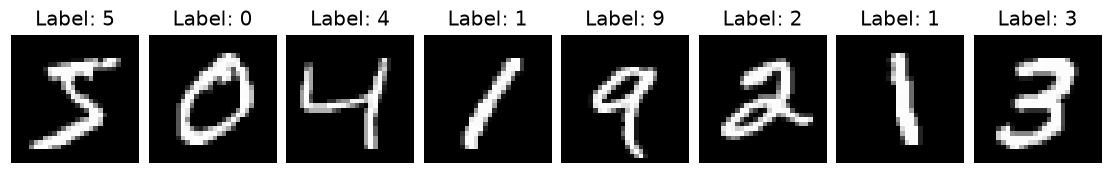

In [3]:
mnist_path = data_dir / "mnist.npz"
if not mnist_path.exists():
    urlretrieve(
        "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz",
        mnist_path,
    )

with np.load(mnist_path, allow_pickle=False) as dataset:
    x_train = dataset["x_train"][..., None].astype(np.float32) / 255
    x_test = dataset["x_test"][..., None].astype(np.float32) / 255
    y_train = dataset["y_train"].astype(np.int32)
    y_test = dataset["y_test"].astype(np.int32)

assert x_train.shape == (60_000, 28, 28, 1) and y_train.shape == (60_000,)
assert x_test.shape == (10_000, 28, 28, 1) and y_test.shape == (10_000,)
experiment_configs.update(train_samples=len(x_train), test_samples=len(x_test))
assert set(y_train) == set(range(10))
print(f"Training images: {len(x_train):,}; test images: {len(x_test):,}")

fig, axes = plt.subplots(1, 8, figsize=(10, 2), layout="constrained")
for ax, image, label in zip(axes, x_train[:8], y_train[:8]):
    ax.imshow(image[..., 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.show()

## Build the visual circuit and input map

Retain left- and right-eye L2 and Tm1 neurons with acetylcholine annotations and all recorded edges between them. L2 inputs require both column coordinates; missing mappings are excluded explicitly. Both eyes receive the same image, so this is bilateral stimulation without stereo information. This is a small visual subcircuit, not the complete visual pathway.

The hex-column projection below is an illustrative planar embedding stretched into the image square independently for each eye, without automatic mirroring. Its orientation and field of view are modeling choices, not a calibrated reconstruction of the fly's retinal image. Body IDs align sampling locations with circuit inputs; response parameters are shared by cell type across eyes.

In [4]:
circuit = CircuitSpec(
    neurons=(
        Q.field("superclass").eq("ol_intrinsic")
        & Q.field("instance").isin(["L2_L", "Tm1_L", "L2_R", "Tm1_R"])
        & Q.field("consensus_nt").eq("acetylcholine")
    ),
    inputs=(
        Q.field("type").eq("L2")
        & ~Q.field("assignedOlHex1").is_null()
        & ~Q.field("assignedOlHex2").is_null()
    ),
    outputs=Q.field("type").eq("Tm1"),
    selection="induced",
)
local_connectome = data_dir / "male-cns-v1.0"
core = FlyModel.from_directory(
    "malecns-1.0",
    circuit=circuit,
    sign_policy={"acetylcholine": 1},
    config=FlyConfig(propagation_steps=3),
)
resolved = core.circuit
assert resolved is not None
annotations = (
    feather.read_table(
        Path(resolved.directory) / "body-annotations-male-cns-v1.0-minconf-0.5.feather",
        columns=["bodyId", "instance", "assignedOlHex1", "assignedOlHex2"],
    )
    .to_pandas()
    .set_index("bodyId")
)
input_annotations = annotations.loc[resolved.input_body_ids]
hex_coordinates = input_annotations[["assignedOlHex1", "assignedOlHex2"]].to_numpy()
input_eyes = input_annotations["instance"].map({"L2_L": "left", "L2_R": "right"})
assert input_eyes.notna().all() and set(input_eyes) == {"left", "right"}
assert np.isfinite(hex_coordinates).all()

hex_1, hex_2 = hex_coordinates.T
image_yx = np.column_stack((np.sqrt(3) * hex_2 / 2, hex_1 - hex_2 / 2))
for eye in ("left", "right"):
    mask = input_eyes.to_numpy() == eye
    eye_coordinates = image_yx[mask]
    span = np.ptp(eye_coordinates, axis=0)
    assert np.all(span > 0), f"Degenerate column coordinates for {eye} eye"
    image_yx[mask] = (eye_coordinates - eye_coordinates.min(axis=0)) / span
input_map = VisualInputMap(
    body_ids=resolved.input_body_ids,
    sampling_coordinates=image_yx,
    neuron_types=("L2",) * core.num_inputs,
    eyes=tuple(input_eyes),
    column_coordinates=hex_coordinates,
    provenance="MaleCNS v1.0; both eyes L2; per-eye hex embedding scaled to [0,1]; y downward; shared image.",
)
model = FlyImageClassifier(
    core,
    input_map,
    num_classes=10,
    rngs=nnx.Rngs(experiment_configs["seed"]),
)
experiment_configs.update(
    eyes="both; shared image",
    num_neurons=core.num_neurons,
    num_inputs=core.num_inputs,
    num_outputs=core.num_outputs,
    propagation_steps=core.config.propagation_steps,
)
assert model(x_train[:2]).logits.shape == (2, 10)
print(f"Circuit: {core.num_neurons:,} neurons, {resolved.num_edges:,} edges")
print(f"Inputs: {core.num_inputs}; readouts: {core.num_outputs}")
output_instances = annotations.loc[resolved.output_body_ids, "instance"]
for eye, instance in (("left", "Tm1_L"), ("right", "Tm1_R")):
    num_inputs = int((input_eyes == eye).sum())
    num_outputs = int((output_instances == instance).sum())
    assert num_inputs > 0 and num_outputs > 0
    print(f"{eye.capitalize()} eye: {num_inputs} inputs, {num_outputs} readouts")

Circuit: 3,556 neurons, 3,758 edges
Inputs: 1767; readouts: 1777
Left eye: 874 inputs, 887 readouts
Right eye: 893 inputs, 890 readouts


## Train with mini-batches

Optimize only `nnx.Param`: image sampling locations and anatomical connectivity stay fixed. Test accuracy is monitored for this tutorial; no model selection is performed. Trackio records the run locally, as in the data-classifier example.

In [5]:
@nnx.jit
def train_step(model, optimizer, images, labels):
    def loss_fn(candidate):
        logits = candidate(images).logits
        return optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()

    loss, gradients = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, gradients)
    return loss


@nnx.jit
def predict_classes(model, images):
    return model.predict(images)


def evaluate_accuracy(model, images, labels):
    correct = 0
    batch_size = experiment_configs["batch_size"]
    for start in range(0, len(images), batch_size):
        stop = start + batch_size
        predictions = np.asarray(
            predict_classes(model, jnp.asarray(images[start:stop]))
        )
        correct += np.count_nonzero(predictions == labels[start:stop])
    return correct / len(labels)

In [6]:
optimizer = nnx.Optimizer(
    model, optax.adam(experiment_configs["learning_rate"]), wrt=nnx.Param
)
shuffle_rng = np.random.default_rng(experiment_configs["seed"])
losses, train_accuracies, test_accuracies = [], [], []
initial_test_accuracy = evaluate_accuracy(model, x_test, y_test)
print(f"Initial test accuracy: {initial_test_accuracy:.1%}")

trackio.init(
    project="flyx-mnist",
    config=experiment_configs,
    embed=False,
    auto_log_gpu=False,
    auto_log_cpu=False,
)
progress = trange(experiment_configs["epochs"], desc="Training")
try:
    for epoch in progress:
        order = shuffle_rng.permutation(len(x_train))
        total_loss = 0.0
        for start in range(0, len(order), experiment_configs["batch_size"]):
            indices = order[start : start + experiment_configs["batch_size"]]
            loss = float(
                train_step(
                    model,
                    optimizer,
                    jnp.asarray(x_train[indices]),
                    jnp.asarray(y_train[indices]),
                )
            )
            total_loss += loss * len(indices)

        loss = total_loss / len(x_train)
        train_accuracy = evaluate_accuracy(model, x_train, y_train)
        test_accuracy = evaluate_accuracy(model, x_test, y_test)
        losses.append(loss)
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)
        trackio.log(
            {
                "epoch": epoch + 1,
                "train/loss": loss,
                "train/accuracy": train_accuracy,
                "test/accuracy": test_accuracy,
            },
            step=epoch + 1,
        )
        progress.set_postfix(loss=f"{loss:.4f}", test_accuracy=f"{test_accuracy:.3f}")
finally:
    trackio.finish()

assert np.isfinite(losses).all()
print(f"Final test accuracy on {len(y_test):,} images: {test_accuracies[-1]:.1%}")

Initial test accuracy: 7.7%
* Trackio project initialized: flyx-mnist
* Trackio metrics logged to: /Users/geekyrakshit/.cache/huggingface/trackio
* View dashboard by running in your terminal:
trackio show --project "flyx-mnist"
* or by running in Python: trackio.show(project="flyx-mnist")
* Created new run: brave-forest-1


Training:   0%|          | 0/5 [00:00<?, ?it/s]

* Run finished. Uploading logs to Trackio (please wait...)
Final test accuracy on 10,000 images: 92.0%


## Inspect learning and predictions

Loss is the sample-weighted mean of training-batch losses; accuracies are measured after each epoch. The prediction grid shows the first twelve held-out images, without selecting for correct predictions.

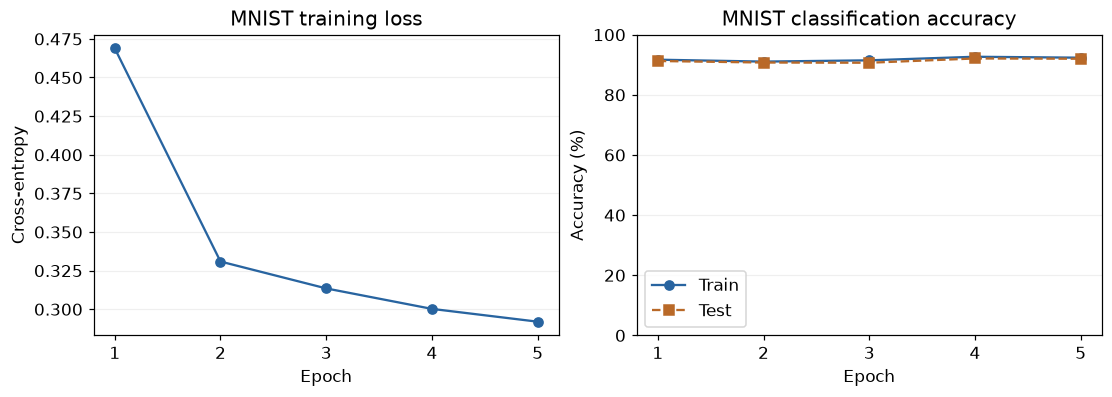

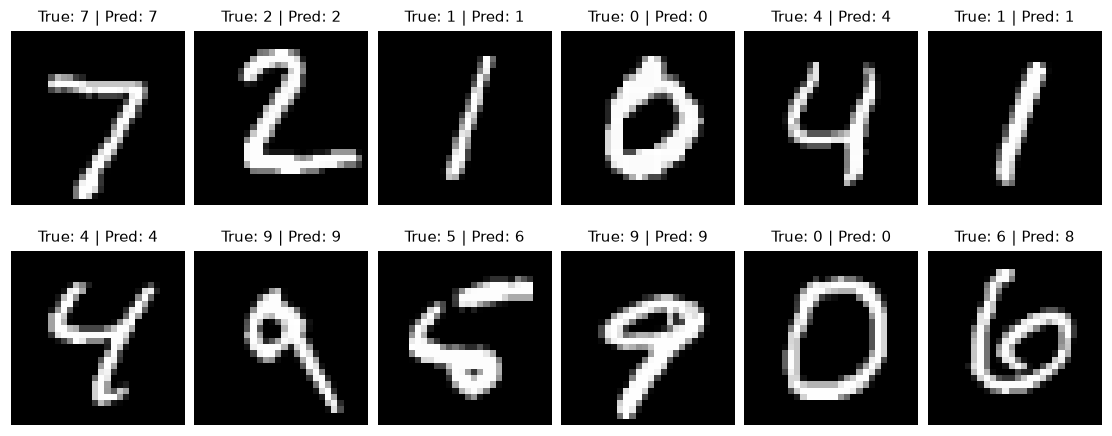

In [7]:
epochs = np.arange(1, len(losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].plot(epochs, losses, "o-", color="#2864a0")
axes[0].set(title="MNIST training loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[1].plot(
    epochs, np.array(train_accuracies) * 100, "o-", color="#2864a0", label="Train"
)
axes[1].plot(
    epochs, np.array(test_accuracies) * 100, "s--", color="#b96928", label="Test"
)
axes[1].set(
    title="MNIST classification accuracy",
    xlabel="Epoch",
    ylabel="Accuracy (%)",
    ylim=(0, 100),
)
axes[1].legend()
for ax in axes:
    ax.set_xticks(epochs)
    ax.grid(axis="y", alpha=0.2)
plt.show()

predictions = np.asarray(predict_classes(model, jnp.asarray(x_test[:12])))
fig, axes = plt.subplots(2, 6, figsize=(10, 4), layout="constrained")
for ax, image, label, prediction in zip(
    axes.flat, x_test[:12], y_test[:12], predictions
):
    ax.imshow(image[..., 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"True: {label} | Pred: {prediction}", fontsize=10)
    ax.axis("off")
plt.show()

Increase the epoch count for a longer run. To assess whether anatomical wiring helps, compare against a conventional image classifier and a control with shuffled input locations. For hyperparameter selection, reserve a validation split from the training data and keep the test set for final evaluation.